In [1]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing
We interpolate then normalize the data. Each is done individually

In [2]:
# Replace with your own files
#!cp "/content/drive/My Drive/ramandata/conor/Train_Inputs.mat" .
#!cp "/content/drive/My Drive/ramandata/conor/Test_Inputs.mat" .

In [3]:
import scipy.io
import os
import numpy as np

base_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Dataset DeepR'
print('Loading DeepR (Only noisy Inputs)...')

# 1. Load the X axis (and flatten it)
asse_X = np.loadtxt(os.path.join(base_dir, 'axis.txt')).flatten()

def load_mat_data(filepath, expected_len):
    mat = scipy.io.loadmat(filepath)
    for k, v in mat.items():
        if not k.startswith('__') and isinstance(v, np.ndarray):
            # Check orientation and transpose if necessary (like in MATLAB)
            if v.shape[1] != expected_len:
                return v.T
            return v
    return None

# 2. Load the Noisy data (Inputs)
tr_in = load_mat_data(os.path.join(base_dir, 'Train_Inputs.mat'), len(asse_X))
te_in = load_mat_data(os.path.join(base_dir, 'Test_Inputs.mat'), len(asse_X))
X_raw = np.vstack((tr_in, te_in))

print(f"X axis shape: {asse_X.shape}")
print(f"Spectra shape (X_raw): {X_raw.shape}")

Loading DeepR (Only noisy Inputs)...
X axis shape: (500,)
Spectra shape (X_raw): (172312, 500)


In [4]:
# This code is no longer needed since the X axis is extracted from TROPHY.mat as asse_X

# def read_axis(filename):
#     """Read the wavelength axis from file."""
#     with open(filename, 'r') as f:
#         wavelengths = np.array([float(line.strip()) for line in f])
#     return wavelengths

# wavelengths = read_axis("/content/drive/My Drive/ramandata/conor/axis.txt")


In [5]:
from scipy import interpolate
from tqdm import tqdm

def interpolate_spectra(spectra_data, old_wavelengths, new_wavelengths):
    # Initialize array for interpolated spectra
    interpolated_spectra = np.zeros((spectra_data.shape[0], len(new_wavelengths)))

    # Interpolate each spectrum
    for i in tqdm(range(spectra_data.shape[0])):
        # Create cubic spline interpolation function
        f = interpolate.CubicSpline(old_wavelengths, spectra_data[i, :])

        # Apply interpolation to new wavelength points
        interpolated_spectra[i, :] = f(new_wavelengths)

    return interpolated_spectra, new_wavelengths

In [6]:
def normalize_raman_spectra(spectra):
    # Create output array
    normalized = np.zeros_like(spectra)

    # Normalize each spectrum individually
    for i in tqdm(range(spectra.shape[0])):
        spectrum = spectra[i, :]
        min_val = np.min(spectrum)
        max_val = np.max(spectrum)

        # Min-max normalization to [0,1] range
        normalized[i, :] = (spectrum - min_val) / (max_val - min_val)

    return normalized

In [7]:
# Adapt the X axis to 1D format
asse_X_flat = asse_X.flatten()

# Global parameters for the new wavelength axis
MIN_WAVE = 650
MAX_WAVE = 1750
NUM_PUNTI = 1000

# Creation of the new equally spaced target axis
asse_target = np.linspace(MIN_WAVE, MAX_WAVE, NUM_PUNTI)
print(f"New target axis created: from {MIN_WAVE} to {MAX_WAVE} with {NUM_PUNTI} points.")

# We use the target axis for interpolation
interpolated_spectra, new_wavelengths = interpolate_spectra(
    X_raw,
    asse_X_flat,
    asse_target
)

New target axis created: from 650 to 1750 with 1000 points.


100%|██████████| 172312/172312 [01:08<00:00, 2529.68it/s]


In [8]:
normalized_spectra = normalize_raman_spectra(interpolated_spectra)
normalized_spectra.shape

100%|██████████| 172312/172312 [00:04<00:00, 35793.77it/s]


(172312, 1000)

In [9]:
import os

# Save path required for DeepR
save_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max'
os.makedirs(save_dir, exist_ok=True) # Create folder if it doesn't exist

save_path = os.path.join(save_dir, 'DeepR_Inputs_1000pt_FingerPrint.npz')

# Save normalized spectra and new x axis (saving as float32)
np.savez(save_path,
          spectra=normalized_spectra.astype(np.float32),
          wavelengths=new_wavelengths.astype(np.float32))

print(f"Data successfully saved to: {save_path}")

Data successfully saved to: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/DeepR_Inputs_1000pt_FingerPrint.npz


### Verification of Saved Data
Let's load the saved file and verify its range and shape to ensure the data was cropped and interpolated correctly.

In [10]:
import numpy as np

# Load the saved file
saved_data = np.load(save_path)
saved_spectra = saved_data['spectra']
saved_wavelengths = saved_data['wavelengths']

# Check the range and shape
print(f"Verification of saved file: {save_path}")
print(f"Spectra shape: {saved_spectra.shape}")
print(f"Wavelengths shape: {saved_wavelengths.shape}")
print(f"Wavelength range: Min = {np.min(saved_wavelengths):.2f}, Max = {np.max(saved_wavelengths):.2f}")

# Assertions to ensure everything matches
assert saved_spectra.shape[1] == NUM_PUNTI, "The number of points in the spectra does not match NUM_PUNTI."
assert np.isclose(np.min(saved_wavelengths), MIN_WAVE), "The minimum wavelength does not match MIN_WAVE."
assert np.isclose(np.max(saved_wavelengths), MAX_WAVE), "The maximum wavelength does not match MAX_WAVE."
print("\nAll checks passed successfully! The data was saved in the correct range.")


Verification of saved file: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/DeepR_Inputs_1000pt_FingerPrint.npz
Spectra shape: (172312, 1000)
Wavelengths shape: (1000,)
Wavelength range: Min = 650.00, Max = 1750.00

All checks passed successfully! The data was saved in the correct range.


# Plot Comparison
These plots are used in Several figures throughout the RamanFoundation paper

In [11]:
import matplotlib.pyplot as plt
plt.style.use('default')

FONTSIZE_AXIS = 15
FONTSIZE_TITLE=15

In [12]:
# Helpers
def get_spectra_from_range(spectra, wavelengths, wavelength_range):
  # Find indices of wavelengths within the range
  indices = np.where((wavelengths >= wavelength_range[0]) &
                     (wavelengths <= wavelength_range[1]))[0]

  # Extract the corresponding spectra
  extracted_spectra = spectra[indices]
  extracted_wavelengths = wavelengths[indices]

  return extracted_wavelengths, extracted_spectra

This plot is used to provide an example of interpolation in Figure 3

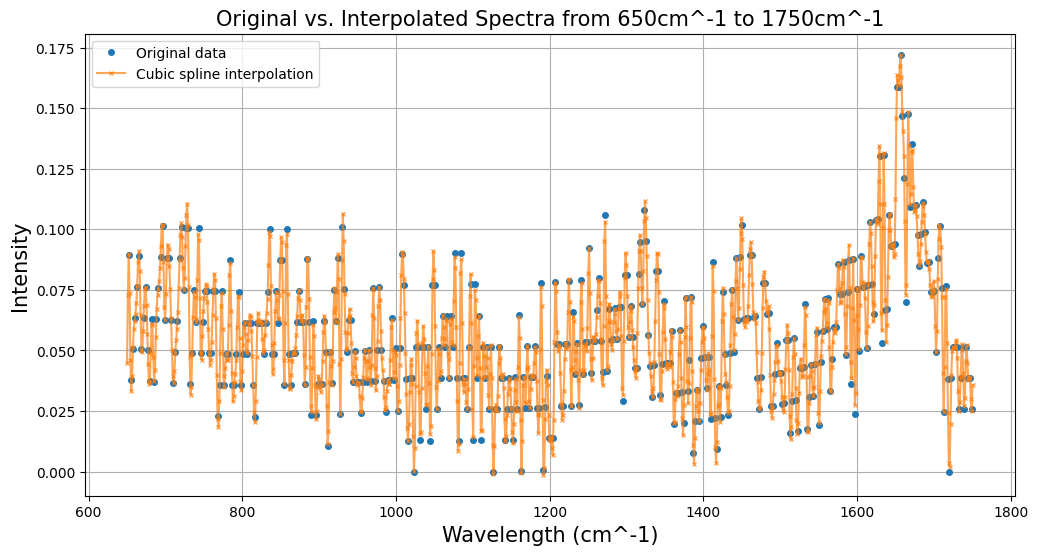

In [13]:
wavelength_range = (MIN_WAVE, MAX_WAVE) # Modified to use the new frequency range
sample_idx = 0

training_sample = X_raw[sample_idx]
interpolated_sample = interpolated_spectra[sample_idx]

wavelengths_original, spectra_original = get_spectra_from_range(training_sample, asse_X_flat, wavelength_range)
wavelengths_interpolated, spectra_interpolated = get_spectra_from_range(interpolated_sample, new_wavelengths, wavelength_range)

plt.figure(figsize=(12,6))
plt.plot(wavelengths_original, spectra_original,
        'o', label='Original data', markersize=4) # Reduced markersize to view dense points better
plt.plot(wavelengths_interpolated, spectra_interpolated,
          'x-', label='Cubic spline interpolation', alpha=0.7, markersize=3) # Restored 'x' marker for interpolated points

plt.xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
plt.ylabel('Intensity', fontsize=FONTSIZE_AXIS)
plt.title(f'Original vs. Interpolated Spectra from {wavelength_range[0]}cm^-1 to {wavelength_range[1]}cm^-1', fontsize=FONTSIZE_TITLE)
plt.legend()
plt.grid(True)
plt.show()

This plot is used to show normalization in Figure 3

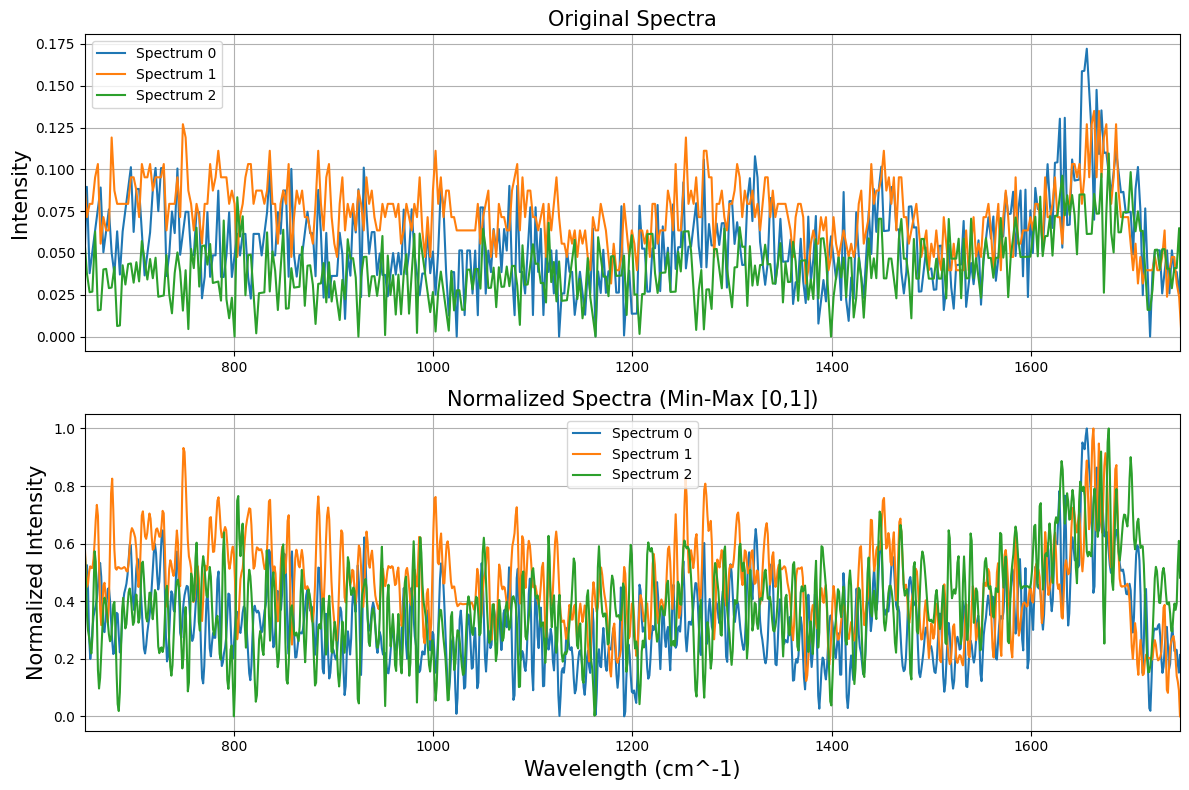

In [14]:
def plot_normalization_comparison(original_spectra, normalized_spectra, sample_indices=[0,1,2]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot original spectra
    for idx in sample_indices:
        ax1.plot(asse_X_flat, original_spectra[idx], label=f'Spectrum {idx}')
    ax1.set_title('Original Spectra', fontsize=FONTSIZE_TITLE)
    ax1.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
    ax1.set_xlim([MIN_WAVE, MAX_WAVE])
    ax1.legend()
    ax1.grid(True)

    # Plot normalized spectra
    for idx in sample_indices:
        ax2.plot(new_wavelengths, normalized_spectra[idx], label=f'Spectrum {idx}')
    ax2.set_title('Normalized Spectra (Min-Max [0,1])', fontsize=FONTSIZE_TITLE)
    ax2.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax2.set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
    ax2.set_xlim([MIN_WAVE, MAX_WAVE])
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Plot comparison
plot_normalization_comparison(X_raw, normalized_spectra)

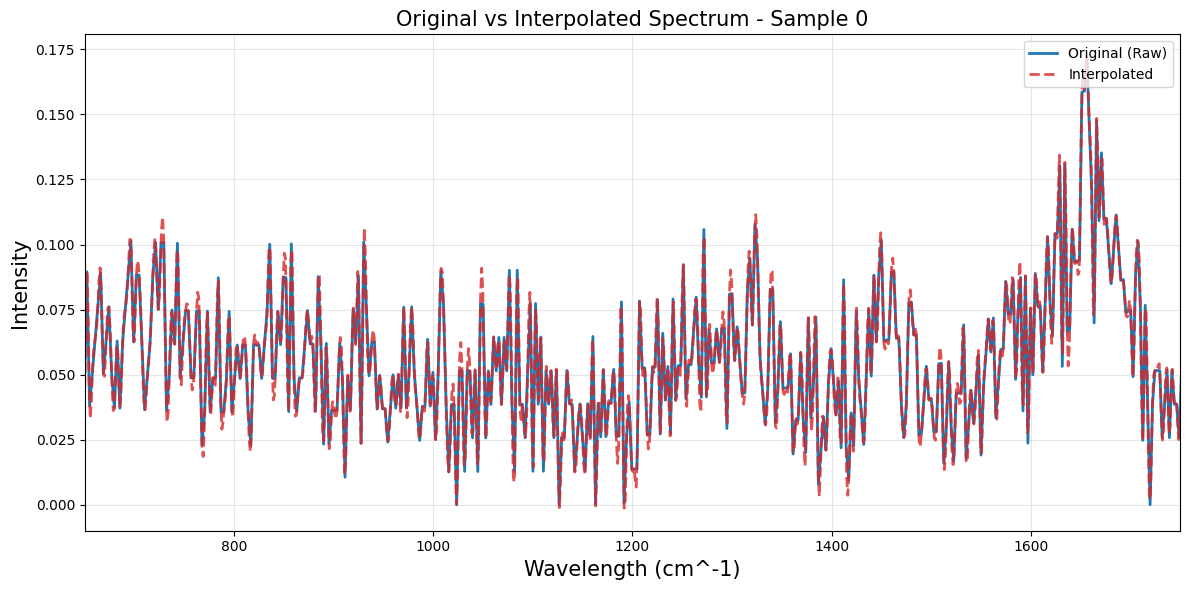

In [15]:
# Overlay of original and interpolated spectra to verify shape preservation
sample_idx = 0
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Original Spectrum
ax.plot(asse_X_flat, X_raw[sample_idx], color='tab:blue', label='Original (Raw)', linewidth=2)

# Plot Interpolated Spectrum
ax.plot(new_wavelengths, interpolated_spectra[sample_idx], color='tab:red', linestyle='--', alpha=0.8, label='Interpolated', linewidth=2)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Original vs Interpolated Spectrum - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()